In [1]:
from pathlib import Path

# adapte si ton notebook n'est pas au même endroit que tes scripts
DATA_ROOT = Path(".") / "data" / "prepared" / "pannuke"
print("DATA_ROOT:", DATA_ROOT.resolve(), "exists:", DATA_ROOT.exists())


DATA_ROOT: C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\data\prepared\pannuke exists: True


In [2]:
import numpy as np
import torch

from src.pannuke_dataset import PannukePreparedDataset


In [3]:
from models.lit_stardist_pannuke import  stardist_train_transform
ds = PannukePreparedDataset(
    root=DATA_ROOT,
    split="train",
    transform=stardist_train_transform,
    load_dists=True,   # doit exister dans ton Dataset
)

out = ds[0]
print("nb outputs:", len(out))

# cas attendu: (img, target, types) après transform
img_t, target, types_t = out

print("img:", img_t.shape, img_t.dtype)
print("fg :", target["foreground"].shape, target["foreground"].dtype)
print("dst:", target["distances"].shape, target["distances"].dtype)
print("R (n_rays):", target["distances"].shape[0])


nb outputs: 3
img: torch.Size([3, 256, 256]) torch.float32
fg : torch.Size([1, 256, 256]) torch.float32
dst: torch.Size([32, 256, 256]) torch.float32
R (n_rays): 32


fg sum: 6336.0 dist max: 37.0 dist mean(nonzero): 20.552004


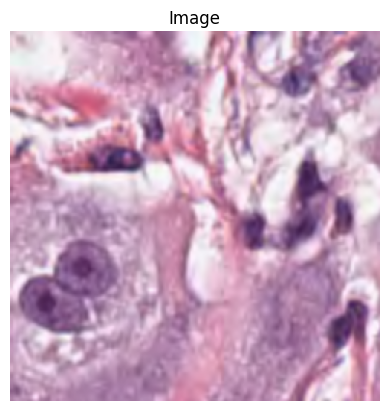

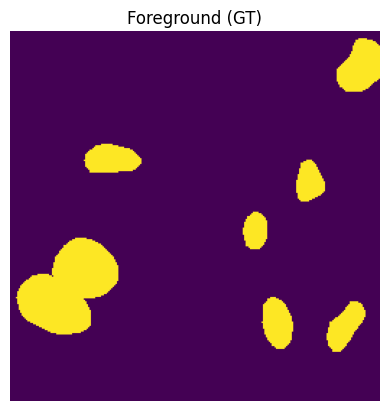

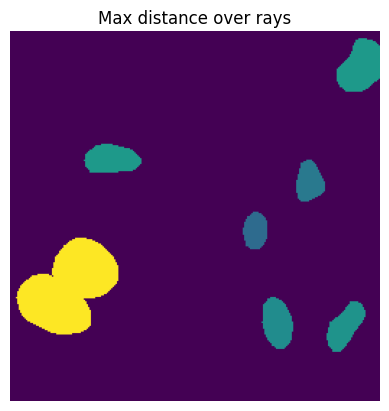

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch

img_t, target, types_t = ds[0]
fg = target["foreground"][0].numpy()
d = target["distances"].numpy()  # (R,H,W)

print("fg sum:", fg.sum(), "dist max:", d.max(), "dist mean(nonzero):", d[d>0].mean() if (d>0).any() else 0)

plt.figure(); plt.title("Image"); plt.imshow(img_t.permute(1,2,0)); plt.axis("off")
plt.figure(); plt.title("Foreground (GT)"); plt.imshow(fg); plt.axis("off")
plt.figure(); plt.title("Max distance over rays"); plt.imshow(d.max(axis=0)); plt.axis("off")
plt.show()


pred instances: 24


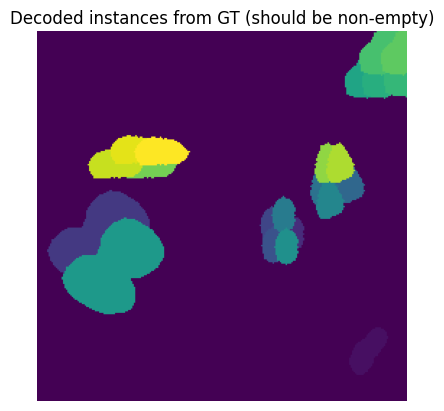

In [5]:
from models.stardist import stardist_decode

prob_map = fg.astype(np.float32)
dist_map = d.astype(np.float32)

pred_inst = stardist_decode(
    prob_map=prob_map,
    dist_map=dist_map,
    prob_thr=0.5,
    nms_iou_thr=0.3,
    max_candidates=3000,
    min_area=10,
)

print("pred instances:", int(pred_inst.max()))
plt.figure(); plt.title("Decoded instances from GT (should be non-empty)"); plt.imshow(pred_inst); plt.axis("off")
plt.show()
